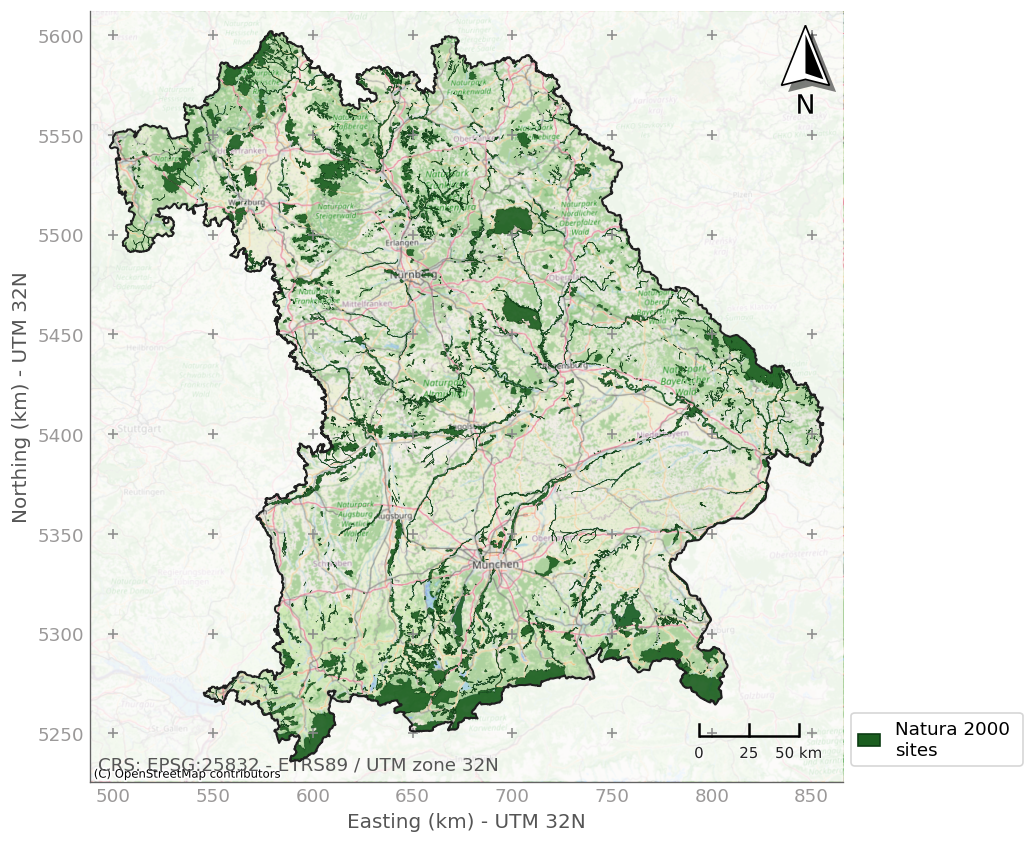

Saved map: C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Figures\natura2000\natura2000.jpg


In [6]:
"""
NHDA distribution in Bavaria based on NHDA centroids.
Template style with grid, north arrow, scale bar, and legend.
"""

import math
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
from shapely.geometry import box

try:
    import contextily as ctx
    HAS_CTX = True
except Exception:
    HAS_CTX = False

try:
    from matplotlib_map_utils import north_arrow, scale_bar
    HAS_MMU = True
except Exception:
    HAS_MMU = False

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 13,
    "axes.titlesize": 19,
    "axes.labelsize": 13,
    "legend.fontsize": 8,
    "legend.title_fontsize": 8,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
})

# ---------------------------------------------------------------------------
# Paths and config
# ---------------------------------------------------------------------------
PATH_LANDKREISE = r"C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Input\Verwaltungsgebiete\vg250-ew_12-31.utm32s.gpkg.ebenen\vg250-ew_ebenen_1231\DE_VG250.gpkg"
LAYER_LANDKREISE = "v_vg250_krs"
PATH_NATURA2000 = r"C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Input\Natura_2000\ffh_epsg25832_shp\ffh_epsg25832_shp.shp"
OUTPUT_DIR = Path(r"C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Figures\natura2000")
OUTPUT_MAP = OUTPUT_DIR / "natura2000.jpg"

COL_ARS = "Regionalschlüssel_ARS"
BAYERN_PREFIX = "09"
TARGET_CRS = "EPSG:25832"
CRS_NOTE = "CRS: EPSG:25832 - ETRS89 / UTM zone 32N"
GRID_STEP_M = 50000
MAP_PADDING_M = 10000
OSM_ZOOM = 8



def add_matplotlib_grid(ax, bounds, step=GRID_STEP_M):
    minx, miny, maxx, maxy = bounds
    x_start = math.ceil(minx / step) * step
    x_end = math.floor(maxx / step) * step
    y_start = math.ceil(miny / step) * step
    y_end = math.floor(maxy / step) * step

    x_major = [x_start + i * step for i in range(int((x_end - x_start) / step) + 1)] if x_start <= x_end else []
    y_major = [y_start + i * step for i in range(int((y_end - y_start) / step) + 1)] if y_start <= y_end else []

    ax.set_xticks(x_major)
    ax.set_yticks(y_major)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(round(x / 1000))}"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{int(round(y / 1000))}"))

    if x_major and y_major:
        x_pts, y_pts = [], []
        for xv in x_major:
            for yv in y_major:
                x_pts.append(xv)
                y_pts.append(yv)
        ax.scatter(x_pts, y_pts, marker="+", s=30, linewidths=1.0, color="#8a8a8a", alpha=0.95, zorder=4, clip_on=True)

    ax.tick_params(axis="both", which="major", labelsize=11, length=0, colors="#9B9999")


def add_north_arrow(ax):
    if HAS_MMU:
        north_arrow(
            ax=ax,
            location='upper right',
            size='md',
            rotation={'degrees': 0},
            aob={
                'bbox_to_anchor': (0.985, 0.985),
                'bbox_transform': ax.transAxes,
                'pad': 0.06,
                'borderpad': 0.06,
                'facecolor': 'none',
                'edgecolor': 'none',
                'alpha': 1.0,
                'frameon': False,
            },
        )
        return

    # Manual north arrow: upward-pointing arrow with 'N' above the tip.
    ax.annotate(
        '',
        xy=(0.945, 0.960),      # arrowhead at top
        xytext=(0.945, 0.880),  # tail at bottom
        xycoords='axes fraction',
        textcoords='axes fraction',
        arrowprops=dict(arrowstyle='-|>', color='#222222', linewidth=1.4, shrinkA=0, shrinkB=0),
        zorder=10,
    )
    ax.text(
        0.945, 0.972,
        'N',
        transform=ax.transAxes,
        ha='center', va='bottom',
        fontsize=14, fontweight='bold', color='#222222',
        zorder=10,
    )


def add_scale_bar(ax):
    if HAS_MMU:
        scale_bar(
            ax=ax,
            location="lower right",
            size="xs",
            style="ticks",
            bar={
                "projection": TARGET_CRS,
                "unit": "km",
                "max": 50,
                "major_div": 2,
                "minor_div": 1,
                "minor_type": "none",
                "reverse": False,
            },
            labels={
                "labels": ["0", "25", "50"],
                "style": "major",
                "loc": "below",
                "fontsize": 9,
            },
            units={"loc": "text", "label": "km"},
            text={"fontfamily": "sans-serif", "fontsize": 9, "textcolor": "#222222"},
            aob={
                "pad": 0.0,
                "borderpad": 1.0,
                "facecolor": "none",
                "edgecolor": "none",
                "alpha": 1.0,
                "frameon": False,
            },
        )
        return

    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    span_x = x1 - x0
    span_y = y1 - y0

    total_km = 50
    segment_km = 25
    bar_len = total_km * 1000
    segment_len = segment_km * 1000

    # Position: shifted left (0.45 from right) and slightly higher (0.06 from bottom)
    x_start = x1 - span_x * 0.35
    y_start = y0 + span_y * 0.060

    ax.plot([x_start, x_start + bar_len], [y_start, y_start], color="#222222", linewidth=1.3, zorder=8)
    tick_h = span_y * 0.006
    for x in [x_start, x_start + segment_len, x_start + bar_len]:
        ax.plot([x, x], [y_start - tick_h, y_start + tick_h], color="#222222", linewidth=1.0, zorder=8)

    txt_y = y_start + span_y * 0.011
    ax.text(x_start, txt_y, "0", ha="center", va="bottom", fontsize=9, color="#222222", zorder=8)
    ax.text(x_start + segment_len, txt_y, "25", ha="center", va="bottom", fontsize=9, color="#222222", zorder=8)
    ax.text(x_start + bar_len, txt_y, "50 km", ha="center", va="bottom", fontsize=9, color="#222222", zorder=8)


def add_scientific_frame(ax, gdf_base):
    ax.set_facecolor("#f1f1f1")
    minx, miny, maxx, maxy = gdf_base.total_bounds
    bounds = (minx - MAP_PADDING_M, miny - MAP_PADDING_M, maxx + MAP_PADDING_M, maxy + MAP_PADDING_M)
    ax.set_xlim(bounds[0], bounds[2])
    ax.set_ylim(bounds[1], bounds[3])
    ax.margins(0)
    add_matplotlib_grid(ax, bounds)

    ax.set_xlim(bounds[0], bounds[2])
    ax.set_ylim(bounds[1], bounds[3])
    ax.set_autoscale_on(False)

    ax.set_xlabel("Easting (km) - UTM 32N", fontsize=12, color="#555555")
    ax.set_ylabel("Northing (km) - UTM 32N", fontsize=12, color="#555555")
    ax.text(0.01, 0.01, CRS_NOTE, transform=ax.transAxes, ha="left", va="bottom", fontsize=11, color="#555555")

    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color("#636262")
        ax.spines[side].set_linewidth(0.8)


def add_legend_upper_left(ax):
    handle = Patch(
        facecolor="#1b5e20",
        edgecolor="#0d3d14",
        label="Natura 2000 \nsites",
    )
    ax.legend(
        handles=[handle],
        loc="lower left",
        bbox_to_anchor=(1.01, 0.02),
        borderaxespad=0.0,
        frameon=True,
        facecolor="white",
        edgecolor="#cccccc",
        fontsize=11,
        handlelength=1.2,
        labelspacing=0.4,
        borderpad=0.4,
    )


# ---------------------------------------------------------------------------
# Load Bavaria boundary (district dissolve)
# ---------------------------------------------------------------------------
gdf_lk = gpd.read_file(PATH_LANDKREISE, layer=LAYER_LANDKREISE)

ars_col = COL_ARS if COL_ARS in gdf_lk.columns else next((c for c in gdf_lk.columns if "ARS" in c or "ars" in c), None)
if ars_col is None:
    raise ValueError("No ARS column found in Landkreis layer.")

gdf_lk = gdf_lk[gdf_lk[ars_col].astype(str).str.startswith(BAYERN_PREFIX)].copy()
if gdf_lk.crs is None or str(gdf_lk.crs) != TARGET_CRS:
    gdf_lk = gdf_lk.to_crs(TARGET_CRS)

gdf_bayern = gdf_lk[["geometry"]].dissolve().reset_index(drop=True)

# ---------------------------------------------------------------------------
# Load NHDA and restrict to Bavaria
# ---------------------------------------------------------------------------
bbox = tuple(gdf_bayern.total_bounds)
gdf_n2000 = gpd.read_file(PATH_NATURA2000, bbox=bbox)

if gdf_n2000.crs is None:
    raise ValueError("NHDA dataset has no CRS. Please define CRS before plotting.")

if gdf_n2000.crs != gdf_bayern.crs:
    gdf_n2000 = gdf_n2000.to_crs(gdf_bayern.crs)

gdf_n2000 = gdf_n2000[gdf_n2000.geometry.intersects(gdf_bayern.geometry.iloc[0])].copy()

# ---------------------------------------------------------------------------
# Plot (template style)
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.6, 9.4))
fig.subplots_adjust(right=0.80, left=0.07, top=0.92, bottom=0.08)

# Set target extent first so contextily computes a valid zoom extent.
minx, miny, maxx, maxy = gdf_bayern.total_bounds
bounds = (minx - MAP_PADDING_M, miny - MAP_PADDING_M, maxx + MAP_PADDING_M, maxy + MAP_PADDING_M)
ax.set_xlim(bounds[0], bounds[2])
ax.set_ylim(bounds[1], bounds[3])

if HAS_CTX:
    ctx.add_basemap(
        ax,
        crs=TARGET_CRS,
        source=ctx.providers.OpenStreetMap.Mapnik,
        zoom=OSM_ZOOM,
        attribution_size=7,
        reset_extent=False,
        zorder=1,
    )
else:
    print("contextily not installed: plotting without OSM basemap.")

# Dim OSM outside Bavaria by overlaying a semi-transparent mask.
frame_poly = box(bounds[0], bounds[1], bounds[2], bounds[3])
outside_geom = frame_poly.difference(gdf_bayern.geometry.iloc[0])
gpd.GeoDataFrame(geometry=[outside_geom], crs=TARGET_CRS).plot(
    ax=ax,
    facecolor="white",
    edgecolor="none",
    alpha=0.8,
    zorder=2,
)

# Natura 2000 polygons on top of OSM basemap.
gdf_n2000.plot(
    ax=ax,
    facecolor="#1b5e20",
    edgecolor="#0d3d14",
    linewidth=0.25,
    alpha=0.9,
    zorder=4,
)

# Boundary for orientation.
gdf_bayern.plot(ax=ax, facecolor="none", edgecolor="#1f1f1f", linewidth=1.2, zorder=5)


add_north_arrow(ax)
add_scale_bar(ax)
add_legend_upper_left(ax)
add_scientific_frame(ax, gdf_bayern)
# ax.set_title("NHDA centroid distribution in Bavaria", fontweight="bold", pad=14)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_MAP, bbox_inches="tight", facecolor="white", format="jpg")
plt.show()

print(f"Saved map: {OUTPUT_MAP}")
